In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [4]:
from tensorflow.keras.datasets import mnist

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [6]:
(X_train, y_train), (X_test, y_test) =mnist.load_data()
print("training Images Shapes: ",X_train.shape)
print("training labels Shapes: ",y_train.shape)
print("testing Images Shapes: ",X_test.shape)
print("testing labels Shapes: ",y_test.shape)

training Images Shapes:  (60000, 28, 28)
training labels Shapes:  (60000,)
testing Images Shapes:  (10000, 28, 28)
testing labels Shapes:  (10000,)


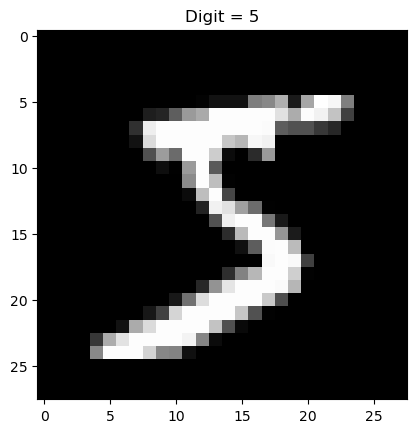

In [7]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Digit = {y_train[0]}")
plt.show()

In [8]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [9]:
print("Max pixel value:",X_train.max())
print("Min pixel value:",X_train.min())

Max pixel value: 1.0
Min pixel value: 0.0


In [10]:
X_train = X_train.reshape(
    X_train.shape[0],28,28,1
)
X_test = X_test.reshape(
    X_test.shape[0],28,28,1
)
print("New shape:",X_train.shape)

New shape: (60000, 28, 28, 1)


In [11]:
model = Sequential()
model.add(
    Conv2D(
        filters = 32,
        kernel_size = (3,3),
        activation = 'relu',
        input_shape = (28,28,1)
    )
)

model.add(
    MaxPooling2D(
    pool_size=(2,2)
    )
)

model.add(
 Conv2D(
     filters=64 ,
     kernel_size=(3,3),
     activation='relu'
     )
)
model.add(
 MaxPooling2D(
    pool_size=(2,2)
 )
)

model.add(
    Flatten()
)

model.add(
    Dense(
        128, activation="relu"
    )
)

model.add(
    Dense(
        18,
        activation="softmax"
    )
)

C:\Users\Roshan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,066 (883.07 KB)

 Trainable params: 226,066 (883.07 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer = "adam",
    loss="sparse_categorical_crossentropy",
    metrics = ['accuracy']
)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs = 5,
    batch_size = 64,
    validation_split = 0.20
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - accuracy: 0.9376 - loss: 0.2021 - val_accuracy: 0.9786 - val_loss: 0.0701
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9831 - loss: 0.0569 - val_accuracy: 0.9819 - val_loss: 0.0615
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 36ms/step - accuracy: 0.9870 - loss: 0.0401 - val_accuracy: 0.9853 - val_loss: 0.0523
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9904 - loss: 0.0300 - val_accuracy: 0.9885 - val_loss: 0.0414
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.9923 - loss: 0.0232 - val_accuracy: 0.9879 - val_loss: 0.0406


In [15]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)
print("\n Test Accuracy:",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9894 - loss: 0.0313

 Test Accuracy: 0.9894000291824341


In [16]:
prediction = model.predict(
    X_test[0].reshape(1,28,28,1)
)
predicted_digit = np.argmax(prediction)
print("Predicted Digit:",predicted_digit)
print("Actual Digit:",y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
Predicted Digit: 7
Actual Digit: 7


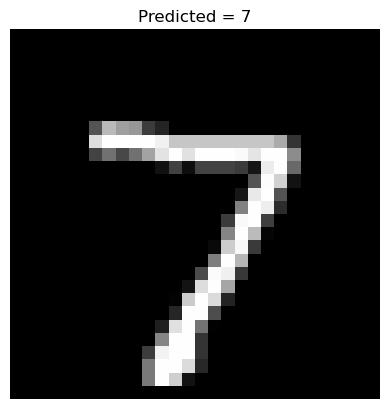

In [18]:
plt.imshow(
    X_test[0].reshape(28,28),
    cmap = "gray",
)
plt.title(
    f"Predicted = {predicted_digit}"
)
plt.axis("off")
plt.show()

In [26]:
for i in range(5):
    prediction = model.predict(X_test[i].reshape(1,28,28,1),
        verbose=0
)
    predicted_digit = np.argmax(prediction)
    print(f"Image {i} | Actual = {y_test[i]} | Predicted = {predicted_digit}")


Image 0 | Actual = 7 | Predicted = 7
Image 1 | Actual = 2 | Predicted = 2
Image 2 | Actual = 1 | Predicted = 1
Image 3 | Actual = 0 | Predicted = 0
Image 4 | Actual = 4 | Predicted = 4
